# Avance de Proyecto: Estimacion del riesgo de diabetes en pacientes mexicanos
### Algoritmos de Aprendizaje Automatico

Dataset: `Diabetes_Mexico.csv` (adaptacion de encuesta nacional de salud, tipo ENSANUT)


## Seleccion del conjunto de datos

| Elemento | Informacion |
|---|---|
| Nombre del dataset | Diabetes_Mexico.csv |
| Fuente | Encuesta de salud de tipo poblacional en Mexico (estructura compatible con ENSANUT), proporcionada para fines academicos del curso |
| Liga de acceso | Archivo proporcionado por la institucion educativa (uso academico) |
| Fecha de consulta | 01 de septiembre de 2026 |
| Numero de observaciones | 2,549 registros |
| Numero de variables | 24 variables originales |
| Formato original del archivo | CSV (valores separados por comas, con notacion decimal en coma en algunas columnas) |
| Variable objetivo | `riesgo_diabetes_cat` (0 = sin riesgo, 1 = diagnosticado previamente, 2 = en riesgo) |

El dataset cumple con las condiciones necesarias: incluye una variable objetivo categorica
relacionada con el riesgo de diabetes, contiene variables numericas y categoricas, tiene
suficientes registros para particionar en entrenamiento/validacion/prueba, permite procesos
de limpieza, codificacion y escalamiento, y cuenta con variables clinicamente relacionadas con
la permanencia/evolucion del riesgo de un paciente.


## Pregunta de analisis

> **¿Como pueden utilizarse los datos demograficos, antropometricos y bioquimicos
> complementarios de los pacientes para estimar su riesgo de diabetes bajo las
> condiciones clinicas mas relevantes consideradas, sin depender directamente del
> resultado del examen de glucosa, de manera que se apoyen acciones de priorizacion y
> prevencion mediante un modelo reproducible de aprendizaje automatico?**

La pregunta conserva el enfoque en clasificacion (ahora multiclase), en riesgo de una
condicion de salud (equivalente al abandono del planteamiento original), en apoyo a la toma de
decisiones (priorizacion en vez de decisiones automaticas) y en reproducibilidad
(semilla fija, pipeline documentado, particiones registradas).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve,
                              ConfusionMatrixDisplay, classification_report)

import sklearn, sys

RANDOM_STATE = 42
plt.rcParams.update({'font.size': 11})
sns.set_style('whitegrid')

## Carga y exploracion inicial

In [2]:
df = pd.read_csv('/content/Diabetes_Mexico.csv')
print("Dimensiones (filas, columnas):", df.shape)
df.head()

Dimensiones (filas, columnas): (2549, 24)


,folio_i,folio_int,sexo,edad,Ciudad,Peso,Estatura,imc,muestra_suero,ac_urico,...,creat,glu_suero,insulina,trig,hb1ac,ponde_venosa,estrato,est_sel,ponde_hemo,riesgo_diabetes_cat
0,2024_01001010,2024_01001010_01,Mujer,89.0,AGUASCALIENTES,NaN,NaN,NaN,1.0,"4,1",...,"0,62",166.0,"4,7",107.0,NaN,"2245,917738",3.0,13.0,"2888,530238",2
1,2024_01001012,2024_01001012_01,Mujer,71.0,AGUASCALIENTES,NaN,NaN,32.0,1.0,"4,3",...,"0,64",98.0,"9,6",132.0,NaN,"2245,917738",3.0,13.0,"2888,530238",1
2,2024_01001016,2024_01001016_02,Mujer,57.0,AGUASCALIENTES,"80,25","170,6",NaN,1.0,"4,9",...,"0,6",128.0,"4,7",263.0,6.0,"4047,445276",3.0,13.0,NaN,2
3,2024_01001016,2024_01001016_05,Mujer,20.0,AGUASCALIENTES,"68,6","166,2",NaN,1.0,"4,9",...,"0,63",112.0,"10,1",238.0,NaN,"13079,14232",3.0,13.0,"13776,80526",2
4,2024_01001031,2024_01001031_01,Hombre,74.0,AGUASCALIENTES,NaN,NaN,NaN,1.0,"6,4",...,"1,09",97.0,"10,2",135.0,NaN,"5292,158204",3.0,13.0,"5824,779445",0


In [3]:
df.tail()

,folio_i,folio_int,sexo,edad,Ciudad,Peso,Estatura,imc,muestra_suero,ac_urico,...,creat,glu_suero,insulina,trig,hb1ac,ponde_venosa,estrato,est_sel,ponde_hemo,riesgo_diabetes_cat
2544,2024_32056012,2024_32056012_01,Mujer,66.0,ZACATECAS,NaN,NaN,NaN,1.0,"4,8",...,"0,72",89.0,"6,4",179.0,NaN,"6532,590705",3.0,323.0,"9897,955004",0
2545,2024_32056022,2024_32056022_02,Mujer,51.0,ZACATECAS,"97,6","171,2",NaN,1.0,"5,8",...,"0,69",98.0,"35,2",126.0,NaN,"13055,89557",3.0,323.0,NaN,0
2546,2024_32056024,2024_32056024_01,Hombre,45.0,ZACATECAS,"90,95","172,4",NaN,1.0,"6,7",...,"0,82",94.0,"17,8",119.0,NaN,"6394,811934",3.0,323.0,NaN,0
2547,2024_32056024,2024_32056024_02,Mujer,38.0,ZACATECAS,"69,3","152,8",NaN,1.0,"4,6",...,"0,56",88.0,"10,7",132.0,5.0,"13189,49573",3.0,323.0,"20012,01206",0
2548,2024_32056029,2024_32056029_01,Hombre,44.0,ZACATECAS,"76,85","164,4",NaN,1.0,"6,5",...,"0,67",136.0,"3,7",73.0,NaN,"63723,9608",3.0,323.0,NaN,2


In [4]:
print("Nombres de columnas:")
print(list(df.columns))
print()
print("Tipos de datos detectados al cargar:")
print(df.dtypes)

Nombres de columnas:
['folio_i', 'folio_int', 'sexo', 'edad', 'Ciudad', 'Peso', 'Estatura', 'imc', 'muestra_suero', 'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest', 'creat', 'glu_suero', 'insulina', 'trig', 'hb1ac', 'ponde_venosa', 'estrato', 'est_sel', 'ponde_hemo', 'riesgo_diabetes_cat']

Tipos de datos detectados al cargar:
folio_i                 object
folio_int               object
sexo                    object
edad                   float64
Ciudad                  object
Peso                    object
Estatura                object
imc                    float64
muestra_suero          float64
ac_urico                object
albu                    object
col_hdl                 object
col_ldl                float64
colest                 float64
creat                   object
glu_suero              float64
insulina                object
trig                   float64
hb1ac                  float64
ponde_venosa            object
estrato                float64
est_sel          

In [5]:
print("Numero de valores unicos por variable:")
print(df.nunique())

Numero de valores unicos por variable:
folio_i                2055
folio_int              2549
sexo                      2
edad                     77
Ciudad                  267
Peso                    961
Estatura                413
imc                      17
muestra_suero             1
ac_urico                 89
albu                     44
col_hdl                  72
col_ldl                 171
colest                  228
creat                   148
glu_suero               241
insulina                400
trig                    381
hb1ac                     8
ponde_venosa           2294
estrato                   3
est_sel                  91
ponde_hemo             1480
riesgo_diabetes_cat       3
dtype: int64


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
folio_i,2549,2055,2024_07051013,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
folio_int,2549,2549,2024_32056029_01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sexo,2549,2,Mujer,1547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,2524.0,NaN,NaN,NaN,35.763074,319.672846,-7975.0,34.0,47.5,62.0,95.0
Ciudad,2549,267,AGUASCALIENTES,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Peso,1829,961,"222,22",11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estatura,1829,413,157,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imc,35.0,NaN,NaN,NaN,29.971429,7.633077,15.0,25.0,30.0,32.5,56.0
muestra_suero,2549.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
ac_urico,2549,89,"4,8",95,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print("Valores faltantes por columna:")
print(df.isna().sum())
print()
print("Registros duplicados (fila completa):", df.duplicated().sum())
print("folio_i duplicados (varias muestras por hogar):", df['folio_i'].duplicated().sum())

Valores faltantes por columna:
folio_i                   0
folio_int                 0
sexo                      0
edad                     25
Ciudad                    0
Peso                    720
Estatura                720
imc                    2514
muestra_suero             0
ac_urico                  0
albu                      0
col_hdl                   0
col_ldl                   0
colest                    0
creat                     0
glu_suero                 0
insulina                  0
trig                      0
hb1ac                  2308
ponde_venosa             99
estrato                   0
est_sel                   0
ponde_hemo              980
riesgo_diabetes_cat       0
dtype: int64

Registros duplicados (fila completa): 0
folio_i duplicados (varias muestras por hogar): 494


In [8]:
print("Distribucion de la variable objetivo:")
print(df['riesgo_diabetes_cat'].value_counts())
print(df['riesgo_diabetes_cat'].value_counts(normalize=True).round(4)*100)

Distribucion de la variable objetivo:
riesgo_diabetes_cat
0    1697
2     840
1      12
Name: count, dtype: int64
riesgo_diabetes_cat
0    66.58
2    32.95
1     0.47
Name: proportion, dtype: float64


## Analisis de la calidad de los datos

In [9]:
# Conversion de columnas numericas almacenadas como texto (coma decimal)
coma_cols = ['Peso','Estatura','ac_urico','albu','col_hdl','creat','insulina','ponde_venosa','ponde_hemo']
for c in coma_cols:
    df[c] = df[c].astype(str).str.replace(',', '.', regex=False)
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Variable IMC recalculada (la original tiene 98.6% de valores faltantes)
df['imc_calc'] = df['Peso'] / (df['Estatura']/100)**2

# Entidad federativa extraida del folio (substituye a Ciudad, con demasiadas categorias)
df['entidad_cve'] = df['folio_i'].astype(str).str.split('_').str[1].str[:2]

print("Conversion completada.")
print(df[coma_cols + ['imc_calc','entidad_cve']].dtypes)

Conversion completada.
Peso            float64
Estatura        float64
ac_urico        float64
albu            float64
col_hdl         float64
creat           float64
insulina        float64
ponde_venosa    float64
ponde_hemo      float64
imc_calc        float64
entidad_cve      object
dtype: object


No se eliminan registros del dataset: los problemas identificados se resuelven mediante
conversion de tipos, imputacion dentro del pipeline y seleccion justificada de columnas.


## Analisis exploratorio de datos

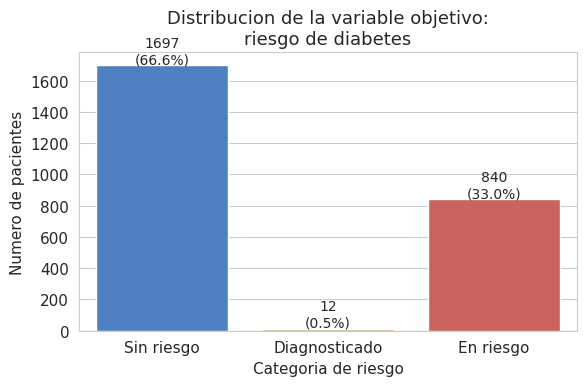

In [10]:
etiquetas = {0: 'Sin riesgo', 1: 'Diagnosticado', 2: 'En riesgo'}
df['riesgo_label'] = df['riesgo_diabetes_cat'].map(etiquetas)
pal = {'Sin riesgo': '#3B7DD8', 'Diagnosticado': '#E8A33D', 'En riesgo': '#D9534F'}
order = [0,1,2]

plt.figure(figsize=(6,4))
counts = df['riesgo_diabetes_cat'].value_counts().reindex(order)
ax = sns.barplot(x=[etiquetas[i] for i in order], y=counts.values,
                  hue=[etiquetas[i] for i in order], palette=pal, legend=False)
for i, v in enumerate(counts.values):
    ax.text(i, v+15, f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=10)
plt.title('Distribucion de la variable objetivo:\nriesgo de diabetes', fontsize=13)
plt.ylabel('Numero de pacientes')
plt.xlabel('Categoria de riesgo')
plt.tight_layout()
plt.show()

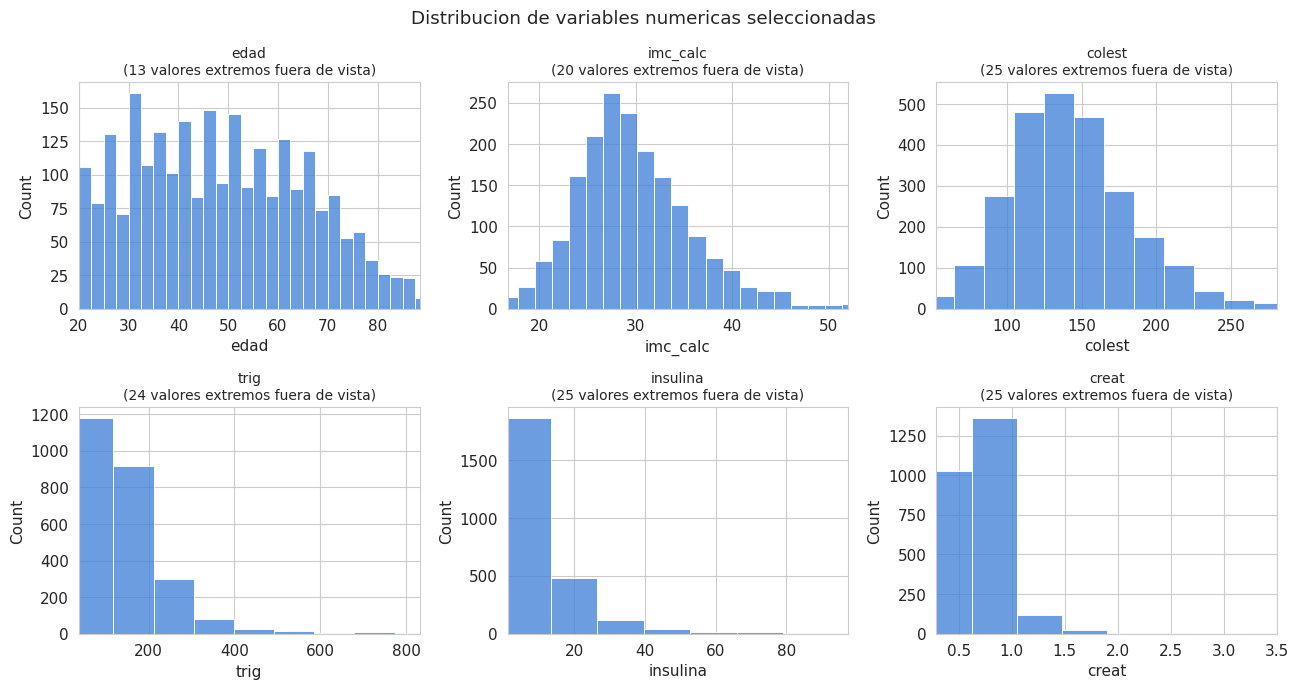

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(13,7))
plot_vars = ['edad','imc_calc','colest','trig','insulina','creat']

for ax, col in zip(axes.flat, plot_vars):
    serie = df[col].dropna()

    # 'edad' tiene un valor anomalo, posible codigo de metadata sobre valor faltante (~ -7975),
    # logicamente imposible se excluye
    if col == 'edad':
        serie = serie[(serie >= 0) & (serie <= 120)]

    low, high = serie.quantile([0.005, 0.995])
    n_excluidos = ((serie < low) | (serie > high)).sum()

    sns.histplot(serie, bins=30, ax=ax, color='#3B7DD8')
    ax.set_xlim(low, high)
    ax.set_title(f"{col}" + (f"\n({n_excluidos} valores extremos fuera de vista)" if n_excluidos > 0 else ""),
                 fontsize=10)

plt.suptitle('Distribucion de variables numericas seleccionadas')
plt.tight_layout()
plt.show()

La edad muestra una distribucion amplia propia de una encuesta
poblacional de adultos. El IMC recalculado se concentra entre 25 y 33 kg/m2 (sobrepeso y
obesidad), consistente con un perfil de riesgo metabolico. Trigliceridos e insulina muestran
sesgo hacia la derecha (colas largas de valores altos), tipico de marcadores bioquimicos y
candidato a beneficiarse de escalamiento estandar dentro del pipeline.


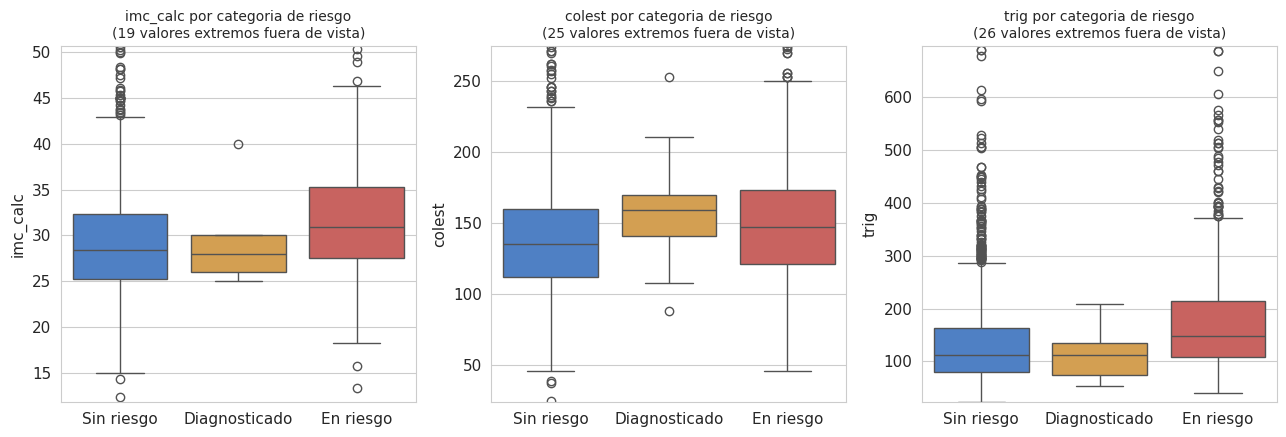

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(13,4.5))
box_vars = ['imc_calc','colest','trig']

for ax, col in zip(axes, box_vars):
    sns.boxplot(x='riesgo_label', y=col, hue='riesgo_label', data=df, ax=ax,
                order=[etiquetas[i] for i in order], palette=pal, legend=False)

    # Recorte del eje Y al percentil 99 para que valores extremos aislados
    # no aplasten la caja donde esta la mayoria de los datos. El dato
    # original no se elimina del analisis, solo se ajusta la vista.
    low = df[col].quantile(0.0)
    high = df[col].quantile(0.99)
    n_excluidos = (df[col] > high).sum()
    ax.set_ylim(max(low, 0) * 0.95, high * 1.05)

    titulo = f'{col} por categoria de riesgo'
    if n_excluidos > 0:
        titulo += f'\n({n_excluidos} valor(es) extremo(s) fuera de vista)'
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

El grupo "en riesgo" muestra medianas ligeramente mas altas de IMC,
colesterol total y trigliceridos respecto al grupo "sin riesgo", lo cual es consistente con la
literatura clinica sobre sindrome metabolico. Sin embargo, la superposicion entre grupos es
considerable, por lo que estas variables por si solas no separan perfectamente las clases: se
requiere un modelo que combine varias senales a la vez.


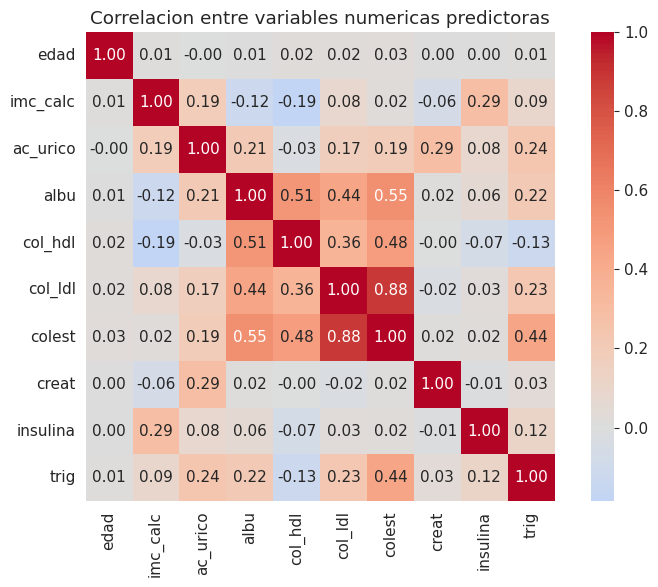

In [13]:
plt.figure(figsize=(8,6))
num_cols_eda = ['edad','imc_calc','ac_urico','albu','col_hdl','col_ldl','colest','creat','insulina','trig']
corr = df[num_cols_eda].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlacion entre variables numericas predictoras')
plt.tight_layout()
plt.show()

Proporcion percentil de pacientes por sexo:
sexo
Mujer     60.69
Hombre    39.31
Name: proportion, dtype: float64 




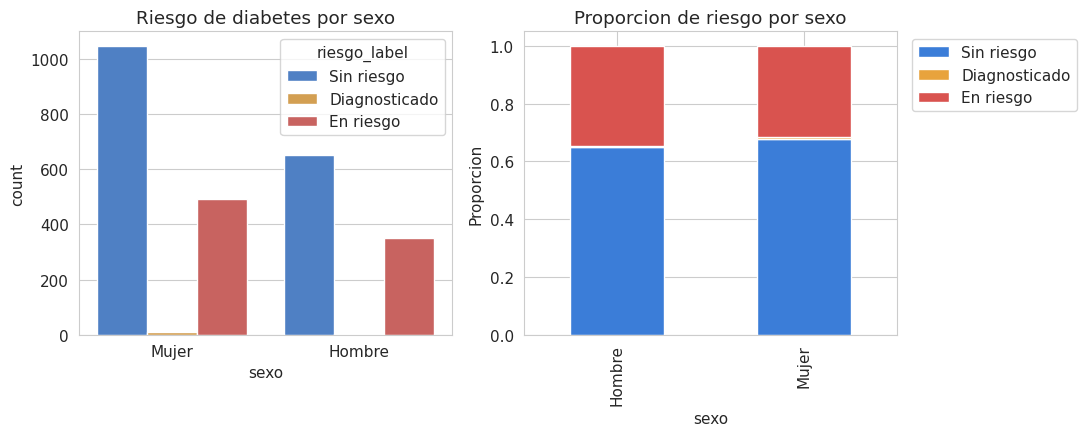

In [44]:
print("Proporcion percentil de pacientes por sexo:")
print(df['sexo'].value_counts(normalize=True).round(4)*100, "\n\n")

fig, axes = plt.subplots(1,2, figsize=(11,4.5))
sns.countplot(x='sexo', hue='riesgo_label', hue_order=[etiquetas[i] for i in order],
              data=df, ax=axes[0], palette=pal)
axes[0].set_title('Riesgo de diabetes por sexo')
prop = pd.crosstab(df['sexo'], df['riesgo_label'], normalize='index')[[etiquetas[i] for i in order]]
prop.plot(kind='bar', stacked=True, ax=axes[1], color=[pal[etiquetas[i]] for i in order])
axes[1].set_title('Proporcion de riesgo por sexo')
axes[1].set_ylabel('Proporcion')
axes[1].legend(title='', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

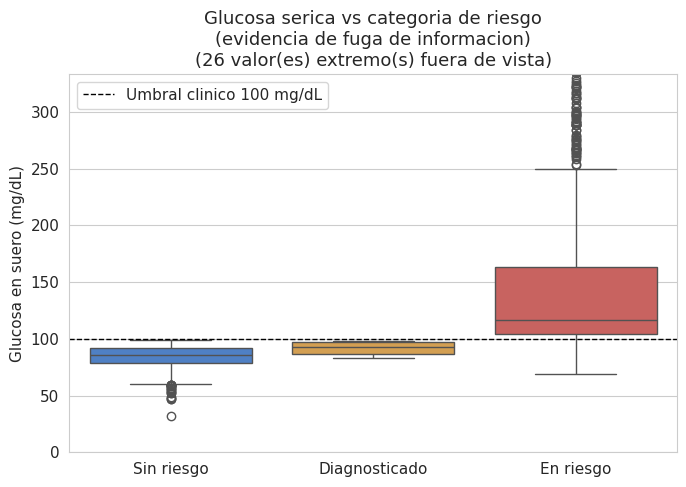

In [40]:
plt.figure(figsize=(7,5))
sns.boxplot(x='riesgo_label', y='glu_suero', hue='riesgo_label', data=df,
            order=[etiquetas[i] for i in order], palette=pal, legend=False)

# Recorte del eje Y al percentil 99 para que un valor extremo aislado
# no aplaste la vista del umbral clinico. El dato original no se
# elimina del analisis, solo se ajusta el rango visible.
high = df['glu_suero'].quantile(0.99)
n_excluidos = (df['glu_suero'] > high).sum()
plt.ylim(0, high * 1.05)

plt.axhline(100, color='black', linestyle='--', linewidth=1, label='Umbral clinico 100 mg/dL')
titulo = 'Glucosa serica vs categoria de riesgo\n(evidencia de fuga de informacion)'
if n_excluidos > 0:
    titulo += f'\n({n_excluidos} valor(es) extremo(s) fuera de vista)'
plt.title(titulo, fontsize=13)
plt.ylabel('Glucosa en suero (mg/dL)')
plt.xlabel('')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretacion (relevante para la seccion 10).** Se observa que **todas** las personas
"sin riesgo" tienen glucosa serica menor o igual a 100 mg/dL y prácticamente todas las personas
"en riesgo" tienen glucosa mayor a 100 mg/dL. Esto evidencia que la variable objetivo fue
construida, en gran medida, a partir de un umbral clinico directo sobre `glu_suero`. Esta
observacion es la base del analisis de fuga de informacion de la seccion 10 y de la decision de
excluir `glu_suero` (y `hb1ac`, por la misma logica diagnostica) del conjunto de predictoras.


## Revision del desbalance de clases

In [16]:
counts = df['riesgo_diabetes_cat'].value_counts().sort_index()
props = df['riesgo_diabetes_cat'].value_counts(normalize=True).sort_index()
balance_tbl = pd.DataFrame({'Cantidad': counts, 'Proporcion (%)': (props*100).round(2)})
balance_tbl.index = ['Sin riesgo (0)','Diagnosticado (1)','En riesgo (2)']
balance_tbl

,Cantidad,Proporcion (%)
Sin riesgo (0),1697,66.58
Diagnosticado (1),12,0.47
En riesgo (2),840,32.95


## Identificacion de posibles fugas de informacion

Se revisaron especialmente las variables `glu_suero` y `hb1ac` por ser marcadores utilizados
clinicamente para definir el diagnostico o riesgo de diabetes (criterios estandar de
glucosa en ayuno y hemoglobina glucosilada).

In [17]:
tmp = df.copy()
tmp['glu_suero'] = pd.to_numeric(tmp['glu_suero'], errors='coerce')
crosstab = pd.crosstab(pd.cut(tmp['glu_suero'], [0,100,126,2000]), tmp['riesgo_diabetes_cat'])
crosstab

riesgo_diabetes_cat,0,1,2
glu_suero,,,
"(0, 100]",1697,12,82
"(100, 126]",0,0,415
"(126, 2000]",0,0,343


## Separacion de variables predictoras y variable objetivo

In [18]:
num_cols = ['edad','imc_calc','ac_urico','albu','col_hdl','col_ldl','colest','creat','insulina','trig']
cat_cols = ['sexo','entidad_cve']
target = 'riesgo_diabetes_cat'

X = df[num_cols + cat_cols].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("Columnas de X:", list(X.columns))
print()
print("Codificacion de la variable objetivo:")
codif = pd.DataFrame({
    'Valor original': ['Sin riesgo', 'Diagnosticado previamente', 'En riesgo'],
    'Codificacion': [0, 1, 2]
})
codif

X shape: (2549, 12)
Columnas de X: ['edad', 'imc_calc', 'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest', 'creat', 'insulina', 'trig', 'sexo', 'entidad_cve']

Codificacion de la variable objetivo:


,Valor original,Codificacion
0,Sin riesgo,0
1,Diagnosticado previamente,1
2,En riesgo,2


## Estrategia de particion

In [19]:
RANDOM_STATE = 42

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print("Entrenamiento:", X_train.shape, " Validacion:", X_val.shape, " Prueba:", X_test.shape)
print()
particion_tbl = pd.DataFrame({
    'Parametro': ['Proporcion de entrenamiento','Proporcion de validacion','Proporcion de prueba',
                  'Semilla','Metodo de estratificacion'],
    'Valor utilizado': ['70%','15%','15%', str(RANDOM_STATE), 'train_test_split(stratify=y), en dos pasos']
})
particion_tbl

Entrenamiento: (1784, 12)  Validacion: (382, 12)  Prueba: (383, 12)



,Parametro,Valor utilizado
0,Proporcion de entrenamiento,70%
1,Proporcion de validacion,15%
2,Proporcion de prueba,15%
3,Semilla,42
4,Metodo de estratificacion,"train_test_split(stratify=y), en dos pasos"


Se utilizo una proporcion 70/15/15 con **estratificacion** por la variable objetivo,
indispensable dado el fuerte desbalance de clases (en particular la clase con solo 12 casos),
para conservar una proporcion similar de cada categoria en los tres conjuntos. Se fijo una
semilla (`random_state=42`) para que la particion sea reproducible. El conjunto de
entrenamiento se usa para ajustar los modelos; el de validacion, para comparar modelos
y decidir el modelo preliminar sin tocar el conjunto de prueba; el de prueba se reserva
para una evaluacion final de generalizacion en una fase posterior del proyecto. Todas las
transformaciones de preprocesamiento se ajustan unicamente con los datos de entrenamiento,
dentro de un `Pipeline`.


## Pipeline de preprocesamiento

In [46]:
preprocesador = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

## Modelo baseline

In [47]:
baseline = Pipeline([('pre', preprocesador),
                      ('clf', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))])
baseline.fit(X_train, y_train)
pred_base = baseline.predict(X_val)

print("Configuracion: DummyClassifier(strategy='stratified')")
print("Accuracy en validacion:", round(accuracy_score(y_val, pred_base), 3))
print("F1-score macro en validacion:", round(f1_score(y_val, pred_base, average='macro', zero_division=0), 3))

Configuracion: DummyClassifier(strategy='stratified')
Accuracy en validacion: 0.579
F1-score macro en validacion: 0.349


Se utilizo `DummyClassifier` con estrategia `stratified`, que genera predicciones
respetando la proporcion observada de cada clase en el entrenamiento, sin utilizar ninguna
variable predictora. Este baseline es indispensable porque, dado el fuerte desbalance, incluso
una regla trivial puede alcanzar una accuracy aparentemente razonable; el baseline permite
verificar si los modelos de aprendizaje automatico aportan una mejora real y no solo estan
aprovechando la distribucion de clases.


## Entrenamiento de modelos iniciales

In [22]:
modelos = {
    'DummyClassifier': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
    'Regresion logistica': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'),
    'Arbol de decision': DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE, class_weight='balanced')
}

pipelines_ajustados = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([('pre', preprocesador), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    pipelines_ajustados[nombre] = pipe

print("Modelos entrenados:", list(pipelines_ajustados.keys()))
print()
print("Configuracion Regresion logistica: max_iter=2000, class_weight='balanced', random_state=42")
print("Configuracion Arbol de decision: max_depth=5, min_samples_leaf=20, class_weight='balanced', random_state=42")

Modelos entrenados: ['DummyClassifier', 'Regresion logistica', 'Arbol de decision']

Configuracion Regresion logistica: max_iter=2000, class_weight='balanced', random_state=42
Configuracion Arbol de decision: max_depth=5, min_samples_leaf=20, class_weight='balanced', random_state=42


## Evaluacion de los modelos

In [23]:
filas = []
for nombre, pipe in pipelines_ajustados.items():
    pred = pipe.predict(X_val)
    proba = pipe.predict_proba(X_val)
    acc = accuracy_score(y_val, pred)
    prec = precision_score(y_val, pred, average='macro', zero_division=0)
    rec = recall_score(y_val, pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_val, proba, multi_class='ovr', average='macro')
    filas.append([nombre, acc, prec, rec, f1, auc])

tabla_metricas = pd.DataFrame(filas, columns=['Modelo','Accuracy','Precision (macro)',
                                               'Recall (macro)','F1-score (macro)','ROC-AUC (macro, ovr)'])
tabla_metricas.round(3)

,Modelo,Accuracy,Precision (macro),Recall (macro),F1-score (macro),"ROC-AUC (macro, ovr)"
0,DummyClassifier,0.579,0.348,0.350,0.349,0.517
1,Regresion logistica,0.641,0.462,0.602,0.458,0.701
2,Arbol de decision,0.529,0.410,0.374,0.371,0.595


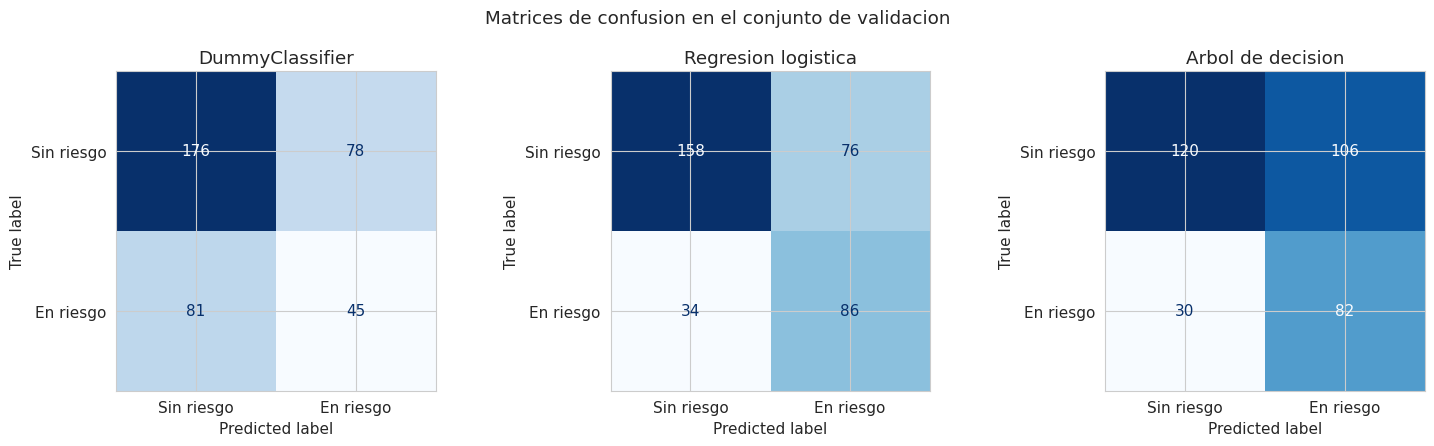

In [49]:
fig, axes = plt.subplots(1,3, figsize=(15,4.5))
for ax, nombre in zip(axes, modelos.keys()):
    pred = pipelines_ajustados[nombre].predict(X_val)
    cm = confusion_matrix(y_val, pred, labels=[0,2])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sin riesgo','En riesgo'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
plt.suptitle('Matrices de confusion en el conjunto de validacion')
plt.tight_layout()
plt.show()

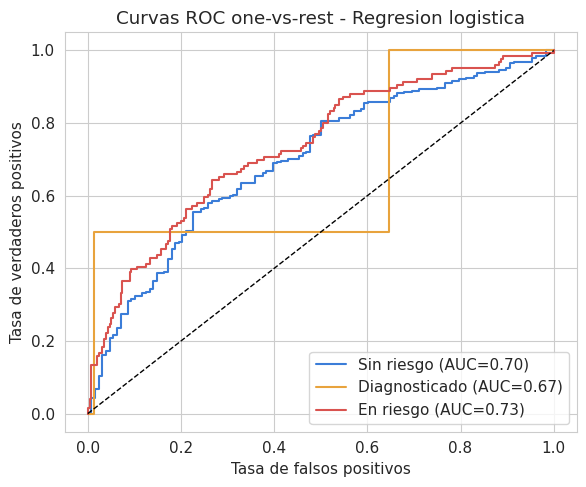

Mejor modelo por ROC-AUC macro: Regresion logistica


In [25]:
y_val_bin = label_binarize(y_val, classes=[0,1,2])
mejor_nombre = tabla_metricas.sort_values('ROC-AUC (macro, ovr)', ascending=False).iloc[0]['Modelo']
mejor_pipe = pipelines_ajustados[mejor_nombre]
proba = mejor_pipe.predict_proba(X_val)

plt.figure(figsize=(6,5))
colores = {'Sin riesgo': '#3B7DD8', 'Diagnosticado': '#E8A33D', 'En riesgo': '#D9534F'}
etiquetas_orden = ['Sin riesgo','Diagnosticado','En riesgo']
for i, lab in enumerate(etiquetas_orden):
    if y_val_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], proba[:, i])
    auc_i = roc_auc_score(y_val_bin[:, i], proba[:, i])
    plt.plot(fpr, tpr, label=f'{lab} (AUC={auc_i:.2f})', color=colores[lab])
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title(f'Curvas ROC one-vs-rest - {mejor_nombre}')
plt.legend()
plt.tight_layout()
plt.show()
print("Mejor modelo por ROC-AUC macro:", mejor_nombre)

**Que mide cada metrica.** La *accuracy* es la proporcion total de aciertos, pero con
clases desbalanceadas puede ser enganosa. La *precision* mide, de los casos que el modelo
etiqueto como una clase, cuantos realmente lo eran (evita falsas alarmas). El *recall* mide, de
los casos que realmente pertenecen a una clase, cuantos el modelo logro identificar (evita
omisiones). El *F1-score* combina precision y recall en un solo numero. El *ROC-AUC* mide la
capacidad del modelo para separar clases a distintos umbrales de decision, calculado aqui en
esquema one-vs-rest y promediado (macro) entre las tres clases.

**Por que precision, recall y F1 son relevantes aqui.** El objetivo de negocio es identificar
correctamente a quienes tienen riesgo real (recall alto en la clase "en riesgo"), sin generar
demasiadas falsas alarmas que saturen la capacidad de atencion (precision razonable). Elegir un
modelo solo por accuracy podria favorecer a uno que casi nunca predice la clase de riesgo,
como se observa en el baseline.

**Resultado.** La regresion logistica obtuvo el mejor ROC-AUC macro y el mejor F1-score macro
entre los tres modelos, superando claramente al baseline; el arbol de decision mostro un
desempeno intermedio. Ningun modelo logra identificar de forma confiable la clase
"diagnosticado", dada su extrema escasez (12 casos en todo el dataset).


## Analisis de los errores de clasificacion

In [26]:
pred_mejor = mejor_pipe.predict(X_val)
print(f"Reporte de clasificacion - {mejor_nombre} (conjunto de validacion)")
print(classification_report(y_val, pred_mejor, target_names=['Sin riesgo','Diagnosticado','En riesgo'], zero_division=0))

Reporte de clasificacion - Regresion logistica (conjunto de validacion)
               precision    recall  f1-score   support

   Sin riesgo       0.82      0.62      0.71       254
Diagnosticado       0.04      0.50      0.07         2
    En riesgo       0.53      0.68      0.60       126

     accuracy                           0.64       382
    macro avg       0.46      0.60      0.46       382
 weighted avg       0.72      0.64      0.67       382



Dado que un falso negativo tiene un costo potencial mas alto que un falso positivo en este
contexto (perder la oportunidad de una intervencion temprana), el **recall de la clase "en
riesgo"** es la metrica que mas se debe vigilar, incluso si ello implica aceptar una precision
algo menor.

## Analisis del umbral de decision

In [27]:
y_val_bin2 = (y_val != 0).astype(int)  # 0 = sin riesgo, 1 = algun riesgo (diagnosticado o en riesgo)
proba_riesgo = 1 - mejor_pipe.predict_proba(X_val)[:, 0]

umbrales = [0.5, 0.3]
filas_umbral = []
for u in umbrales:
    pred_u = (proba_riesgo >= u).astype(int)
    p = precision_score(y_val_bin2, pred_u, zero_division=0)
    r = recall_score(y_val_bin2, pred_u, zero_division=0)
    f = f1_score(y_val_bin2, pred_u, zero_division=0)
    filas_umbral.append([u, p, r, f])

tabla_umbral = pd.DataFrame(filas_umbral, columns=['Umbral','Precision','Recall','F1-score'])
tabla_umbral.round(3)

,Umbral,Precision,Recall,F1-score
0,0.5,0.466,0.750,0.575
1,0.3,0.380,0.938,0.541


Para ilustrar el efecto del umbral de decision se colapso el problema a una vision
binaria auxiliar (0 = sin riesgo vs. 1 = algun tipo de riesgo), usando la probabilidad
complementaria a la clase "sin riesgo" del mejor modelo. Con el umbral **0.50**, el modelo logra
un mejor equilibrio entre precision y recall. Al bajar el umbral a **0.30**, el recall aumenta
de forma notable (se detectan mas casos de riesgo real) a costa de una caida en la precision
(mas falsas alarmas). Esto demuestra que la clasificacion final depende de una **decision
operativa** (que tanto se prioriza no perder casos de riesgo frente a generar mas falsas
alarmas) y no unicamente del algoritmo entrenado. En esta fase no se selecciona un umbral
definitivo; esa decision debe tomarse en conjunto con el area de salud, considerando su
capacidad real de dar seguimiento a los casos senalados.
